# Лабораторная работа 2. Исследовательский анализ данных

**Вариант 14.** Набор данных `clients.csv` содержит сведения о клиентах магазина: идентификатор, год рождения, образование, семейное положение, доход семьи, количество детей, дату регистрации и количество покупок по акциям.

Цель работы — исследовать распределения и взаимосвязи признаков средствами pandas, matplotlib и seaborn.


In [1]:
# Импорт необходимых библиотек
# pandas — загрузка и обработка данных
# numpy — числовые вычисления
# matplotlib.pyplot — построение графиков
# seaborn — статистическая визуализация данных

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 1 Загрузка и предварительная обработка


In [2]:
# Загрузка исходного набора данных
df = pd.read_csv('clients.csv', sep=';')
print('Размер исходного набора:', df.shape)
df.info()
display(df.describe(include='all'))


Размер исходного набора: (796, 8)
<class 'pandas.DataFrame'>
RangeIndex: 796 entries, 0 to 795
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 796 non-null    int64  
 1   Year_Birth         796 non-null    int64  
 2   Education          796 non-null    str    
 3   Marital_Status     796 non-null    str    
 4   Income             784 non-null    float64
 5   Kidhome            795 non-null    float64
 6   Dt_Customer        795 non-null    str    
 7   NumDealsPurchases  795 non-null    float64
dtypes: float64(3), int64(2), str(3)
memory usage: 49.9 KB


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Dt_Customer,NumDealsPurchases
count,796.000000,796.000000,796,796,784.00000,795.000000,795,795.000000
unique,NaN,NaN,4,8,NaN,NaN,469,NaN
top,NaN,NaN,Graduation,Married,NaN,NaN,02.01.2013,NaN
freq,NaN,NaN,444,305,NaN,NaN,6,NaN
mean,5630.133166,1968.356784,NaN,NaN,53130.07398,0.438994,NaN,2.314465
std,3273.039715,12.022132,NaN,NaN,21818.56876,0.547252,NaN,1.941650
min,0.000000,1899.000000,NaN,NaN,2447.00000,0.000000,NaN,0.000000
25%,2853.000000,1959.000000,NaN,NaN,36141.75000,0.000000,NaN,1.000000
50%,5563.000000,1969.500000,NaN,NaN,52372.50000,0.000000,NaN,2.000000
75%,8584.250000,1977.000000,NaN,NaN,69293.25000,1.000000,NaN,3.000000


Файл clients.csv считывается с разделителем ;, после чего проверяются размер набора, типы столбцов, пропуски и основные статистические характеристики. Исходный набор содержит 796 строк и 8 столбцов.


In [3]:
# Очистка и подготовка данных
df.columns = df.columns.str.lower()
df = df.drop_duplicates().reset_index(drop=True)
df['education'] = df['education'].str.strip().replace({'2n Cycle': 'Graduation'})
df['marital_status'] = df['marital_status'].str.strip().replace({'MARRIED': 'Married', 'SINGL': 'Single', 'Alone': 'Single'})
df = df.dropna(subset=['dt_customer']).reset_index(drop=True)
for col in ['income', 'kidhome', 'numdealspurchases']:
    df[col] = df[col].fillna(df[col].median())
df['dt_customer'] = pd.to_datetime(df['dt_customer'], format='%d.%m.%Y')
df['income'] = df['income'].round().astype(int)
df['kidhome'] = df['kidhome'].round().astype(int)
df['numdealspurchases'] = df['numdealspurchases'].round().astype(int)
df['income_level'] = pd.qcut(df['income'], q=3, labels=['Низкий', 'Средний', 'Высокий'])
print('Размер после обработки:', df.shape)
display(df.head())


Размер после обработки: (791, 9)


,id,year_birth,education,marital_status,income,kidhome,dt_customer,numdealspurchases,income_level
0,5524,1957,Graduation,Single,58138,0,2012-09-04,3,Средний
1,2174,1954,Graduation,Single,46344,1,2014-03-08,2,Средний
2,4141,1965,Graduation,Together,71613,0,2013-08-21,1,Высокий
3,6182,1984,Graduation,Together,26646,1,2014-02-10,2,Низкий
4,5324,1981,PhD,Married,58293,1,2014-01-19,5,Средний


Названия столбцов приведены к нижнему регистру, удалены дубликаты и одна строка без даты регистрации. Категориальные значения семейного положения нормализованы, пропуски числовых признаков заполнены медианами, дата преобразована в datetime64. Дополнительно создан income_level с тремя квантильными уровнями дохода. После обработки осталось 791 наблюдение.


## 2 Матрица рассеяния и категориальная диаграмма


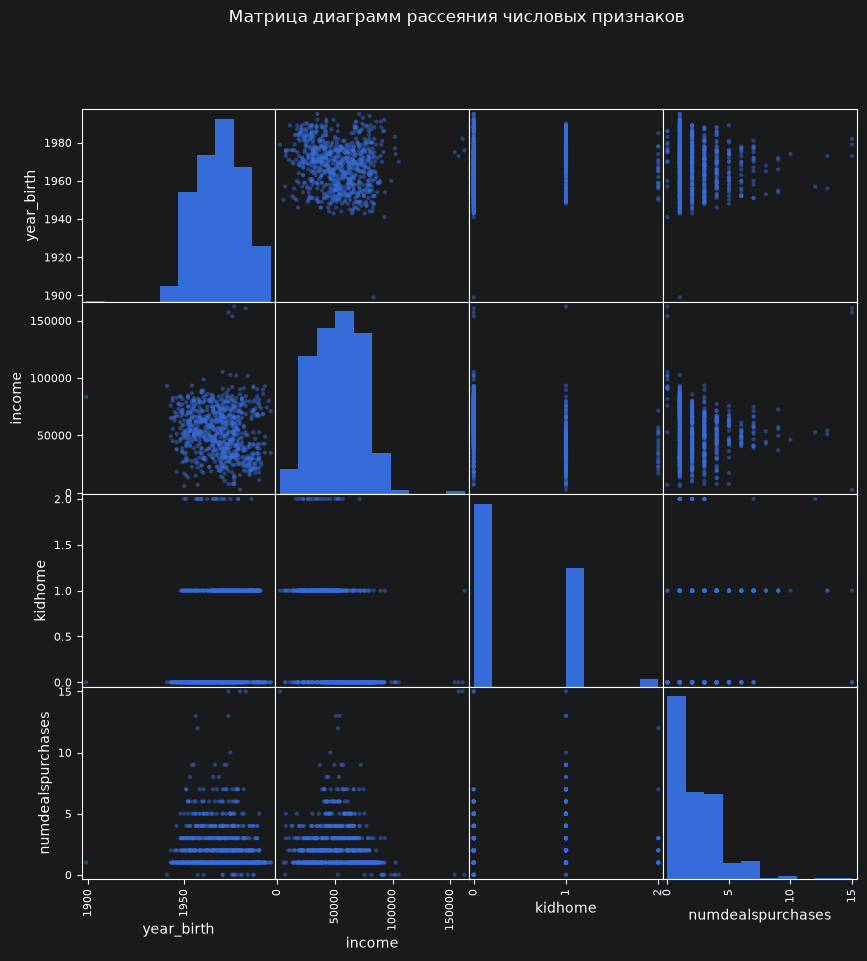

In [4]:
# Рисунок 1: матрица диаграмм рассеяния
numeric = ['year_birth', 'income', 'kidhome', 'numdealspurchases']
pd.plotting.scatter_matrix(df[numeric], figsize=(10, 10), diagonal='hist')
plt.suptitle('Матрица диаграмм рассеяния числовых признаков')
plt.show()


Матрица показывает попарные зависимости числовых признаков: на диагонали расположены гистограммы, вне диагонали — облака точек. Между income и numdealspurchases наблюдается практически отсутствующая отрицательная связь (r = -0.054), а между year_birth и income выраженной линейной зависимости нет (r = -0.143). Наиболее заметна обратная связь income и kidhome (r = -0.528). Также видны отдельные выбросы, включая год рождения 1899 и высокие значения дохода.


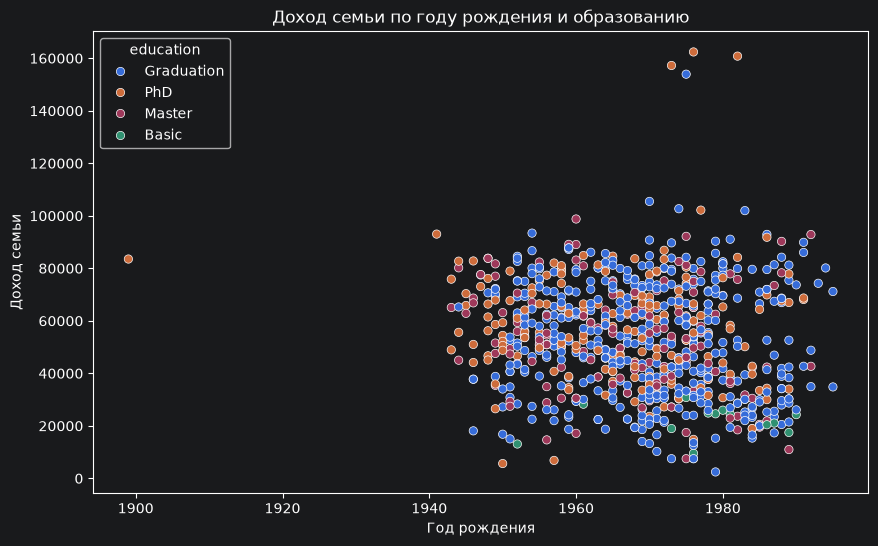

In [5]:
# Рисунок 2: доход по году рождения и уровню образования
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='year_birth', y='income', hue='education')
plt.title('Доход семьи по году рождения и образованию')
plt.xlabel('Год рождения')
plt.ylabel('Доход семьи')
plt.show()


Каждая точка соответствует клиенту, а цвет показывает уровень образования. Облака точек образовательных групп сильно перекрываются: у PhD медианный доход выше, а у Basic ниже, но внутри групп сохраняется большой разброс. Поэтому год рождения и образование по отдельности не объясняют весь разброс дохода.


## 3 Гистограммы, корреляция и ковариация


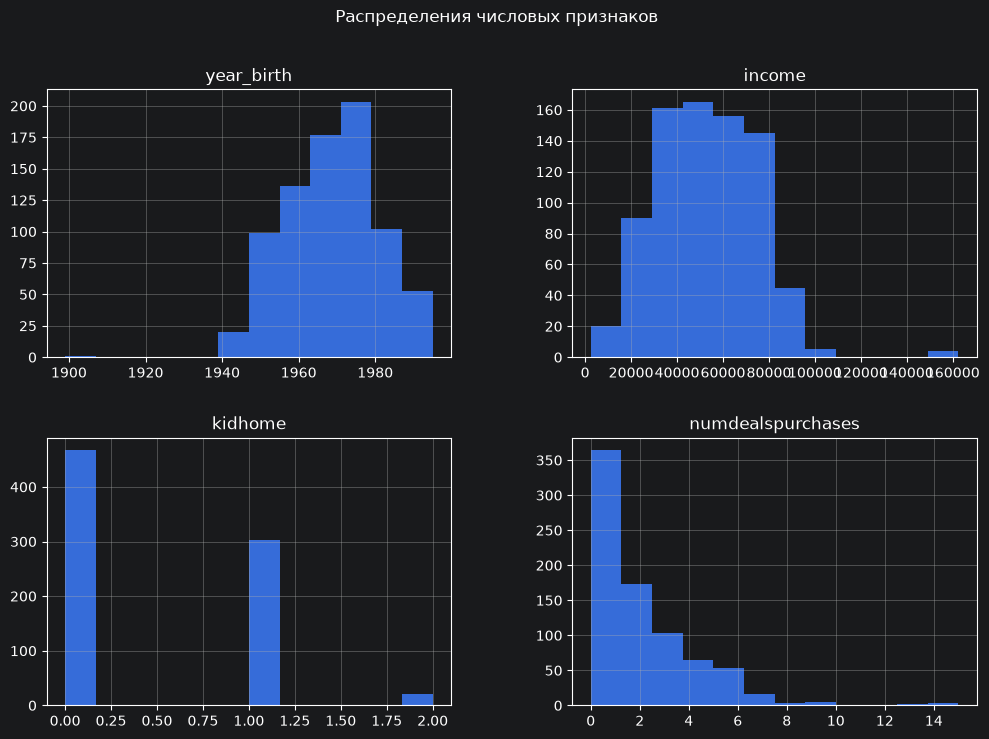

In [6]:
# Рисунок 3: гистограммы числовых признаков
numeric = ['year_birth', 'income', 'kidhome', 'numdealspurchases']
df[numeric].hist(bins=12, figsize=(12, 8))
plt.suptitle('Распределения числовых признаков')
plt.show()


Гистограмма income имеет правый хвост: медиана равна 52 614, а среднее — 53 129.80, поэтому несколько высоких значений немного увеличивают среднее. Для kidhome медиана равна 0, а для numdealspurchases — 2; типичный клиент не имеет детей дома и совершает около двух покупок по акциям.


In [7]:
# Расчет матриц корреляции и ковариации
print('Матрица корреляции:')
print(df[numeric].corr().round(3))
print('\nМатрица ковариации:')
print(df[numeric].cov().round(2))


Матрица корреляции:
                   year_birth  income  kidhome  numdealspurchases
year_birth              1.000  -0.143    0.246             -0.061
income                 -0.143   1.000   -0.528             -0.054
kidhome                 0.246  -0.528    1.000              0.198
numdealspurchases      -0.061  -0.054    0.198              1.000

Матрица ковариации:
                   year_birth        income  kidhome  numdealspurchases
year_birth             144.48 -3.728977e+04     1.62              -1.42
income              -37289.77  4.718261e+08 -6279.35           -2263.22
kidhome                  1.62 -6.279350e+03     0.30               0.21
numdealspurchases       -1.42 -2.263220e+03     0.21               3.79


Наиболее заметна обратная линейная связь income и kidhome (r = -0.528). Связи year_birth — income (r = -0.143), income — numdealspurchases (r = -0.054) и kidhome — numdealspurchases (r = 0.198) слабые. Ковариация показывает направление совместного изменения признаков, но зависит от единиц измерения, поэтому силу связей удобнее сравнивать по корреляции.


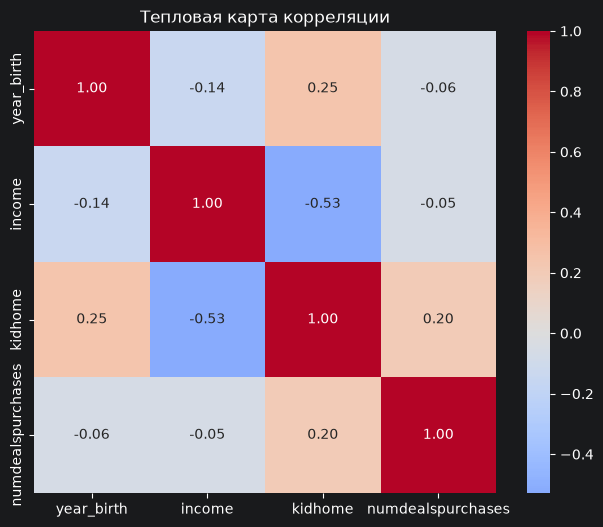

In [8]:
# Рисунок 4: тепловая карта корреляции
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Тепловая карта корреляции')
plt.show()


Тепловая карта позволяет быстро сравнить направление и силу линейных связей. Самая заметная ячейка income и kidhome соответствует обратной связи средней силы; остальные коэффициенты находятся ближе к нулю. Корреляция описывает статистическую связь и не доказывает причинность.


## 4 Дополнительные виды графиков


<Figure size 900x600 with 0 Axes>

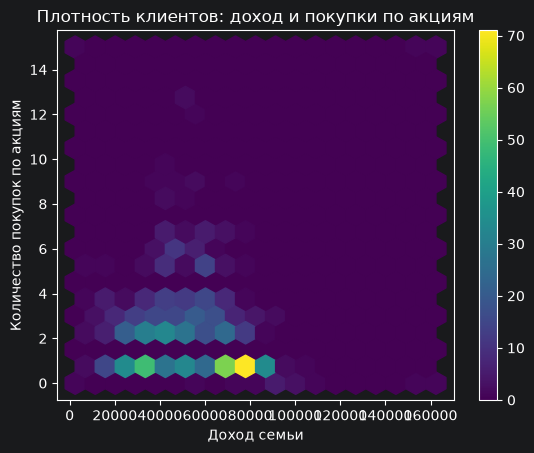

In [9]:
# Рисунок 5: hexbin-график дохода и покупок по акциям
plt.figure(figsize=(9, 6))
df.plot(x='income', y='numdealspurchases', kind='hexbin',
        gridsize=18, cmap='viridis', sharex=False)
plt.title('Плотность клиентов: доход и покупки по акциям')
plt.xlabel('Доход семьи')
plt.ylabel('Количество покупок по акциям')
plt.show()


 Hexbin-график объединяет близкие наблюдения в шестиугольные ячейки и показывает плотность клиентов. Основная масса наблюдений находится около дохода 30–70 тыс. и 0–4 покупок по акциям. Редкие области справа соответствуют клиентам с очень высоким доходом и формируют правый хвост распределения.


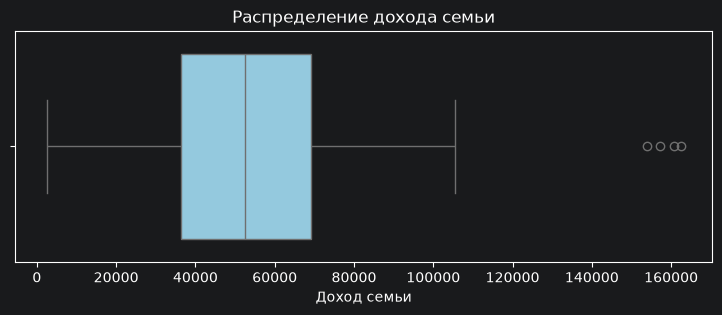

In [10]:
# Рисунок 6: общий boxplot дохода
plt.figure(figsize=(9, 3))
sns.boxplot(x=df['income'], color='skyblue')
plt.title('Распределение дохода семьи')
plt.xlabel('Доход семьи')
plt.show()


 Общая диаграмма размаха показывает медиану дохода 52 614. Центральная половина наблюдений находится примерно между 36 257 и 69 119, а отдельные значения выше верхнего квартиля являются высокими наблюдениями, которые следует учитывать при интерпретации среднего.


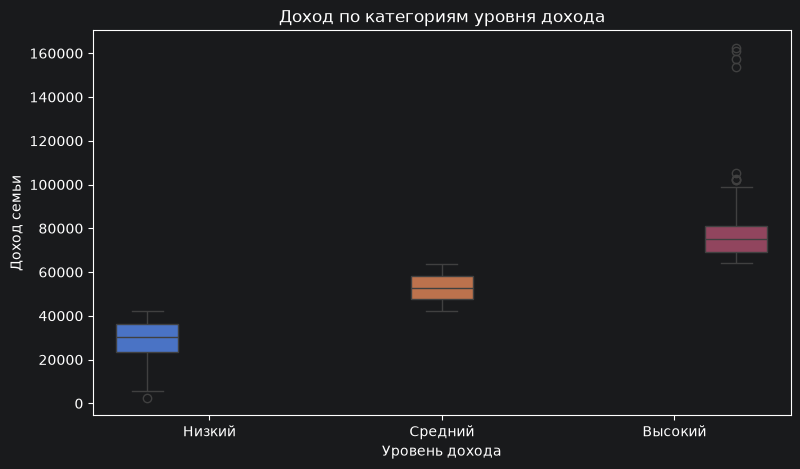

In [11]:
# Рисунок 7: boxplot по категориям дохода
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='income_level', y='income',
            hue='income_level', legend=False)
plt.title('Доход по категориям уровня дохода')
plt.xlabel('Уровень дохода')
plt.ylabel('Доход семьи')
plt.show()


Категории дохода сформированы по квантилям, поэтому в них почти одинаковое число клиентов: 264, 263 и 264. Медианы составляют около 30 515, 52 614 и 75 100. Категории удобны для сегментации, но расстояния между уровнями неодинаковы в денежных единицах.


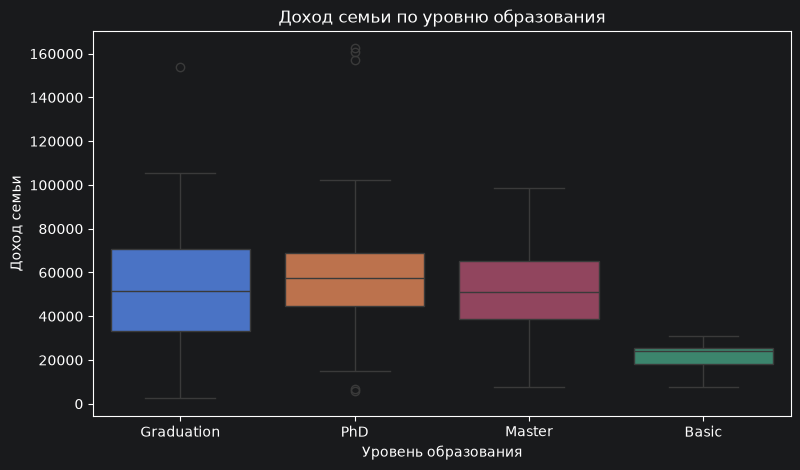

In [12]:
# Рисунок 8: boxplot дохода по образованию
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='education', y='income',
            hue='education', legend=False)
plt.title('Доход семьи по уровню образования')
plt.xlabel('Уровень образования')
plt.ylabel('Доход семьи')
plt.show()


Медианный доход наиболее низок у Basic (24 279), а наиболее высок у PhD (57 424.5). У Graduation и Master медианы близки: 51 766 и 51 124. Диапазоны групп заметно перекрываются, поэтому образование связано с доходом, но не определяет его однозначно.


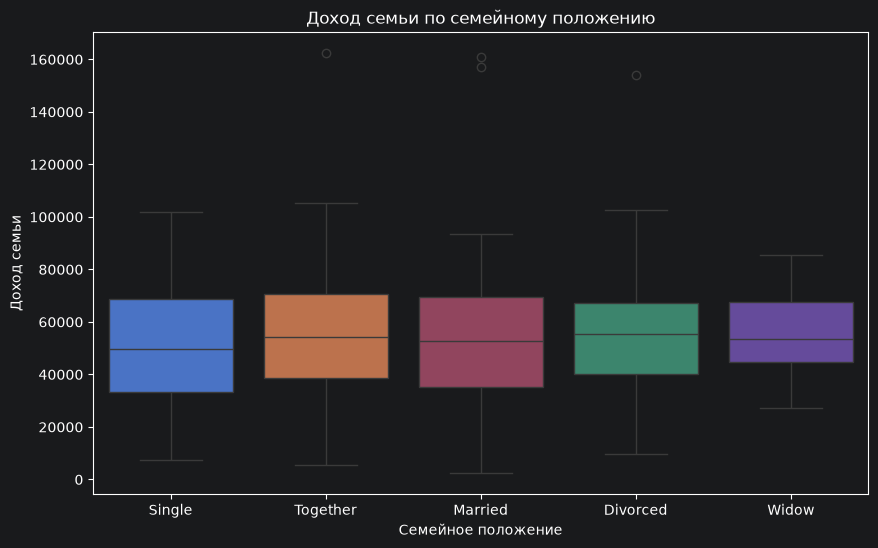

In [13]:
# Рисунок 9: boxplot дохода по семейному положению
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='marital_status', y='income',
            hue='marital_status', legend=False)
plt.title('Доход семьи по семейному положению')
plt.xlabel('Семейное положение')
plt.ylabel('Доход семьи')
plt.show()


Boxplot показывает различия медиан дохода по семейному положению: медиана минимальна у Single (49 580.5), а максимальна у Divorced (55 412). Распределения групп заметно перекрываются. Средние значения, рассчитанные отдельно в задании 2, изменяются от 50 990.66 у Single до 55 452.45 у Widow; эти показатели нельзя напрямую считывать с boxplot.


## 5 Задания варианта 14


### Задание 1. Количество клиентов по образованию и семейному статусу


     education marital_status  count
0        Basic       Divorced      1
1        Basic        Married      9
2        Basic         Single      1
3        Basic       Together      4
4        Basic          Widow      0
5   Graduation       Divorced     49
6   Graduation        Married    170
7   Graduation         Single    103
8   Graduation       Together     96
9   Graduation          Widow     21
10      Master       Divorced     12
11      Master        Married     57
12      Master         Single     32
13      Master       Together     42
14      Master          Widow      4
15         PhD       Divorced     23
16         PhD        Married     70
17         PhD         Single     42
18         PhD       Together     51
19         PhD          Widow      4


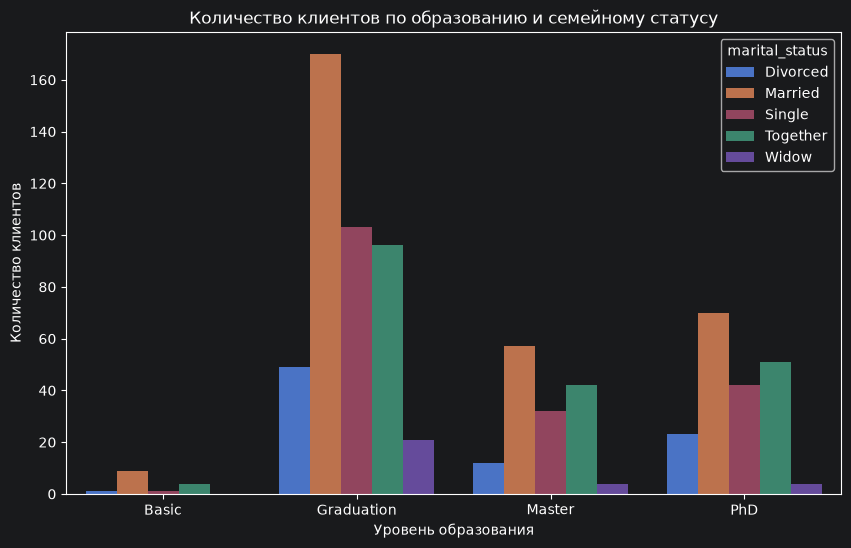

In [14]:
# Задание 1: группировка и график средствами seaborn
education_order = sorted(df['education'].unique())
marital_order = sorted(df['marital_status'].unique())
all_combinations = pd.MultiIndex.from_product(
    [education_order, marital_order],
    names=['education', 'marital_status']
)
task1 = (df.groupby(['education', 'marital_status']).size()
         .reindex(all_combinations, fill_value=0)
         .rename('count')
         .reset_index())
print(task1)

plt.figure(figsize=(10, 6))
sns.barplot(data=task1, x='education', y='count',
            hue='marital_status', order=education_order,
            hue_order=marital_order, estimator=sum, errorbar=None)
plt.title('Количество клиентов по образованию и семейному статусу')
plt.xlabel('Уровень образования')
plt.ylabel('Количество клиентов')
plt.show()


Сначала сформирована таблица task1 с количеством клиентов для каждой пары education и marital_status. Затем именно эта сгруппированная таблица передана в seaborn.barplot. Включение нулевых комбинаций позволяет отобразить все семейные статусы для каждого уровня образования. Наиболее многочисленна категория Graduation, а крупнейшая комбинация — Graduation и Married (170 клиентов).


### Задание 2. Средний доход по семейному положению


                  income
marital_status          
Divorced        54568.16
Married         52894.63
Single          50990.66
Together        54493.05
Widow           55452.45


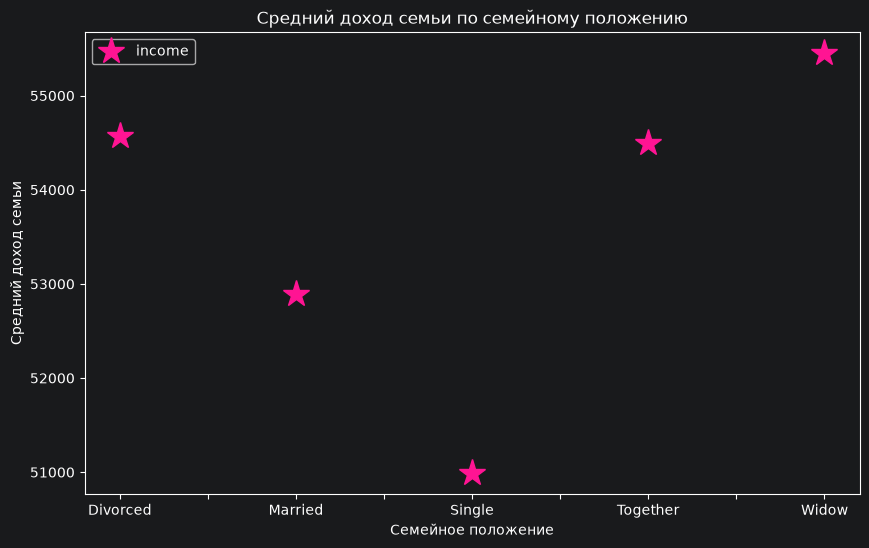

In [15]:
# Задание 2: pivot_table и график средствами pandas.plot
task2 = df.pivot_table(index='marital_status', values='income',
                        aggfunc='mean').round(2)
print(task2)

task2.plot(kind='line', linestyle='', marker='*', markersize=20,
           color='deeppink', figsize=(10, 6))
plt.title('Средний доход семьи по семейному положению')
plt.xlabel('Семейное положение')
plt.ylabel('Средний доход семьи')
plt.show()


С помощью pivot_table рассчитан средний доход по каждому семейному положению. Для визуализации использован pandas.plot: маркеры имеют форму звезды (marker='*'), размер 20 и цвет deeppink. Максимальное среднее значение у Widow — 55 452.45, минимальное у Single — 50 990.66.


### Задание 3. Образование клиентов, имеющих детей


education
Graduation    183
PhD            69
Master         63
Basic           9
Name: count, dtype: int64


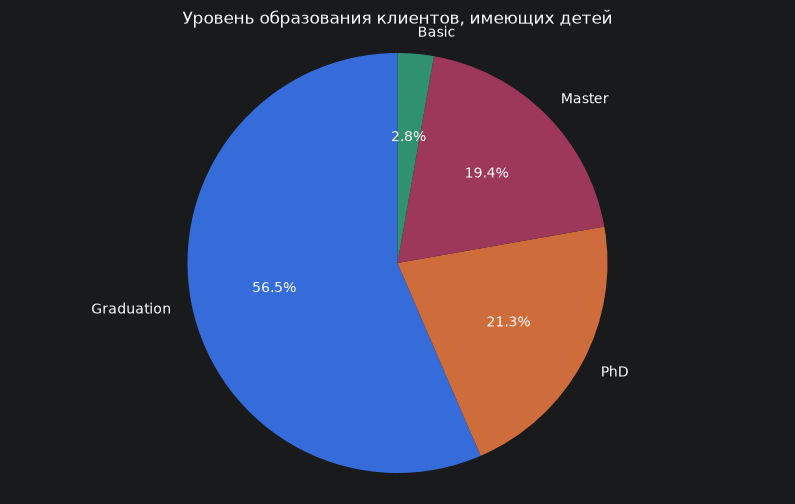

In [16]:
# Задание 3: фильтрация и круговая диаграмма средствами matplotlib
task3 = df[df['kidhome'] > 0]['education'].value_counts()
print(task3)

plt.figure(figsize=(10, 6))
plt.pie(task3.values, labels=task3.index,
        autopct='%1.1f%%', startangle=90)
plt.title('Уровень образования клиентов, имеющих детей')
plt.ylabel('')
plt.axis('equal')
plt.show()


Из набора отобраны клиенты, у которых количество детей больше нуля (kidhome > 0). Проценты уровней образования показаны круговой диаграммой, построенной непосредственно средствами matplotlib через plt.pie. В подгруппе преобладает Graduation — 183 клиента, или 56.5%.


## 6 Вывод


В работе выполнен исследовательский анализ набора clients.csv: данные загружены с разделителем точка с запятой, проверены размеры, типы, пропуски и дубликаты. После удаления одной строки без даты регистрации и четырёх дубликатов осталось 791 наблюдение. Дата регистрации преобразована к типу datetime64, категориальные значения нормализованы, пропуски числовых признаков заполнены медианами. Такой порядок обработки сохранил основную часть выборки и сделал данные пригодными для визуального анализа.

Для изучения структуры данных построены матрица рассеяния, категориальный scatter plot, гистограммы, тепловая карта корреляций, hexbin-график и диаграммы размаха. Анализ показал правостороннюю асимметрию дохода и наличие отдельных высоких значений. Наиболее заметная линейная связь — обратная связь дохода и количества детей (r = -0.528); связи дохода с годом рождения и покупками по акциям слабые. Образование и семейное положение связаны с различиями дохода описательно, но сильное перекрытие диапазонов показывает, что эти признаки не объясняют его полностью.

Задания варианта 14 выполнены полностью: построена группировка клиентов по образованию и семейному статусу, рассчитан средний доход по семейному положению с помощью pivot_table и построена круговая диаграмма образования клиентов с детьми средствами matplotlib. Наиболее многочисленна категория Graduation — 439 клиентов. Среди клиентов с детьми она также занимает основную долю — 56.5%. При интерпретации результатов учтены размеры групп: например, категория Widow содержит 29 клиентов, а Basic — 15, поэтому оценки для них менее устойчивы. Полученные выводы описывают данную выборку и не должны автоматически обобщаться на всех клиентов магазина.
